# Applied Data Science - Exercise 5

This is the fifth and final exercise in the course T-786-APDS Applied Data Science at Reykjavik University.

## Preparation

Please refer to the lecture slides from the course for the lab. 

## Task

You continue on your mission to predict listed car prices. As before, you will be using the second hand car listing data crawled from Craigslist (`vehicles.csv`).

To recap our progress so far, we have:

* Explored the dataset, visualized the data, and gained insights
* Prepared the data for machine learning algorithms
* Used the Scikit-learn library to train a few different regression models on our training data and tuned hyper-parameters using cross-validation.
* Interpreted the resulting models to gain understanding of our models (e.g. why different predictions were being made).

In this exercise, you will recap and integrate what you have learned across previous assignments, plus new methods introduced here.

You are tasked with creating the best prediction model possible based on your intiutions around exploring the data, playing with the different models and understanding of the model outcomes. 

Remember: You are a good modeler when you can explain it well to even a layperson.


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import sys

In [67]:
# Check python version.
# This code should run for python version >=3.6

print("python", sys.version)

python 3.12.1 (main, Dec 12 2023, 14:10:04) [Clang 13.0.0 (clang-1300.0.29.30)]


## Data import and preprocessing

We start by importing the data and getting it ready for machine learning as before. 

**Task:** But now you are required to add/change some of the steps in the preprocessing step (possibly encoding methods) based on your subjective exploration done in Assignment 1 and 2: 

In [ ]:
vehicles = pd.read_csv("../Ass1/vehicles.csv", index_col=0)

In [ ]:
reduced_df = vehicles.copy()
reduced_df = reduced_df[reduced_df['price'] > 0]
reduced_df = reduced_df[reduced_df['price'].notna()]
reduced_df = reduced_df[reduced_df['price'] < 1000000]
reduced_df = reduced_df[~reduced_df.manufacturer.isnull()]  
reduced_df = reduced_df.drop(columns=[
    'county', 
    'id', 
    'region_url', 
    'url', 
    'image_url', 
    'VIN'
])

**Question:**  Would adding the msrp dataset to our reduced_df help in our price prediction task? Why or Why not?

**Answer:**  `Yes, adding the MSRP data would probably help. We saw in assignment 2 that there was a clear correlation between MSRP and the price, and some features like engine horsepower also had a strong correlation. We would however also lose a lot of data since many listings don't have a matching entry in the MSRP dataset, which could hurt the model since we would have less training data.`

In [ ]:
from sklearn.model_selection import train_test_split

vehicles_train_set, vehicles_test_set = train_test_split(reduced_df, test_size=0.1, random_state=123)
vehicles_train_set, vehicles_val_set = train_test_split(vehicles_train_set, train_size=0.95) 

In [ ]:
def preprocess(df_in):
    
    df = df_in.copy()
    
    N = 50
    topN_models = df.model.value_counts().head(N).index.to_numpy()
    df.loc[~df['model'].isin(topN_models),'model'] = 'unknown'
    top_models = list(vehicles_train_set.model.unique())
    
    df = df.drop(columns=[
        'size', 
        'drive', 
        'lat', 
        'long', 
        'posting_date', 
        'paint_color', 
        'description',
        'state',
        'region'
    ])
    
    df.loc[~df['model'].isin(top_models),'model'] = 'unknown'
    
    df = df.dropna(subset=['year', 'odometer','manufacturer'])
    df['type'] = df['type'].fillna('unknown')
    df['title_status'] = df['title_status'].fillna('clean')
    df['fuel'] = df['fuel'].fillna('gas')
    df['cylinders'] = df['cylinders'].fillna('unknown')
    df['transmission'] = df['transmission'].fillna('automatic')
    df['condition'] = df['condition'].fillna('good')

    condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']
    df['condition'] = df['condition'].map({c: i for i, c in enumerate(condition_order)}) #Change condition from one-hot encoding to ordinal encoding
    
    
    X = df.drop('price', axis=1)
    y = df['price'].copy()
    
    return(X,y)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X, y = preprocess(vehicles_train_set)

num_attribs = list(X.select_dtypes('number'))
cat_attribs = list(X.select_dtypes('object'))


pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs)
])

X_prepared = pipeline.fit_transform(X)

/var/folders/7v/25vl4fsd1jv9jsr72bhy8wkw0000gn/T/ipykernel_90909/85700525.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_attribs = list(X.select_dtypes('object'))


**Question:**  What did you change in the above code to preprocess the dataset? How do you justify your action?

**Answer:**  `I added ordinal encoding for the condition column instead of one-hot encoding. Since condition has a natural ordering from worst to best (salvage < fair < good < excellent < like new < new), it makes more sense to represent this as ordered numbers (0–5) rather than separate binary columns, which would treat all conditions as equally different from each other.`

## Model building and hyperparameter optimisation

**Task:** Pick a model from Assignment 3 that you believe would suit this task well. Train your model on the training set and choose a set of hyperparameters. Justify the selection of hyperparameters. 

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X_train, y_train = preprocess(vehicles_train_set)
X_train_prepared = pipeline.fit_transform(X_train)

rfrmodel = RandomForestRegressor(n_estimators=15, max_features=50, random_state=42)
rfrmodel.fit(X_train_prepared, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",15
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",50
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

`I chose RandomForestRegressor because it gave the best results in Assignment 3 with a mean RMSE of ~6607. I kept n_estimators=15 and max_features=50 as these were the best hyperparameters found in Assignment 3. A low n_estimators keeps training time manageable, and max_features=50 controls how many features each tree considers at each split, which helps reduce overfitting compared to using all features.`

**Task:** Evaluate your model on the validation set to diagnose underfitting or overfitting

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Training RMSE
y_train_pred = rfrmodel.predict(X_train_prepared)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print('Training RMSE:', train_rmse)

# Validation RMSE
X_val, y_val = preprocess(vehicles_val_set)
X_val_prepared = pipeline.transform(X_val)
y_val_pred = rfrmodel.predict(X_val_prepared)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print('Validation RMSE:', val_rmse)

Training RMSE: 2597.0167824649116
Validation RMSE: 9875.371182667122


**Question:**  What are the RMSE value from the above sets? Can we do a direct comparison of these values to validate the model?

**Answer:**  `The training RMSE is 2597 and the Validation RMSE is 9875. The large gap between them seems to suggest that the model is overfitting. We can compare these values to each other to diagnose overfitting, but we cannot use them to validate the final model performance since the validation set was used to guide our modeling decisions. For that we would need to evaluate on the test set, which we have not touched yet.`

**Task:** Use nested cross-validation to select the best hyperparameters and estimate the error on a RandomForestRegressor model. 

Hint: Use the whole training set (vehicles_train_set) for this task. 

(this could be computationally expensive, so you can use a subset of the training set for this task or use number of splits wisely)

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor

X_cv, y_cv = preprocess(vehicles_train_set)
X_cv_prepared = pipeline.transform(X_cv)

X_cv_prepared = X_cv_prepared[:5000]
y_cv = y_cv.iloc[:5000] # Use a subset to keep it fast, only 5000 samples

# 1. Define the inner and outer CV strategies
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [10, 15],
    'max_features': [10, 50]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=inner_cv, scoring='neg_mean_squared_error')

nested_scores = cross_val_score(grid_search, X_cv_prepared, y_cv, cv=outer_cv, scoring='neg_mean_squared_error')

print("Best nested CV RMSE:", np.sqrt(-nested_scores.mean()))

grid_search.fit(X_cv_prepared, y_cv)
print("Best params:", grid_search.best_params_)

Best nested CV RMSE: 8882.087787329701
Best params: {'max_features': 50, 'n_estimators': 15}


We find the best model. We fit it to the training data and call the model est

In [ ]:
forest_reg = RandomForestRegressor(max_features=50 , n_estimators=15, random_state=42)
est = forest_reg.fit(X_train_prepared, y_train)

Apply the model to the test data

In [ ]:
X_test, y_test = preprocess(vehicles_test_set)
X_test_prepared = pipeline.transform(X_test)

y_test_pred = forest_reg.predict(X_test_prepared)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print('Test RMSE:', test_rmse)

Test RMSE: 6259.121095449658


## Methods for model interpretation

SHAP

The goal of SHAP is to explain the prediction of an instance x by computing the contribution of each feature to the prediction.

The SHAP explanation method computes Shapley values from coalitional game theory

Shapley values tell us how to fairly distribute the “payout” (= the prediction) among the features

In [ ]:
import shap
# This takes a while to run
explainer = shap.Explainer(est)
shap_values = explainer.shap_values(X_train_prepared[:100].toarray(), approximate=False, check_additivity=False)

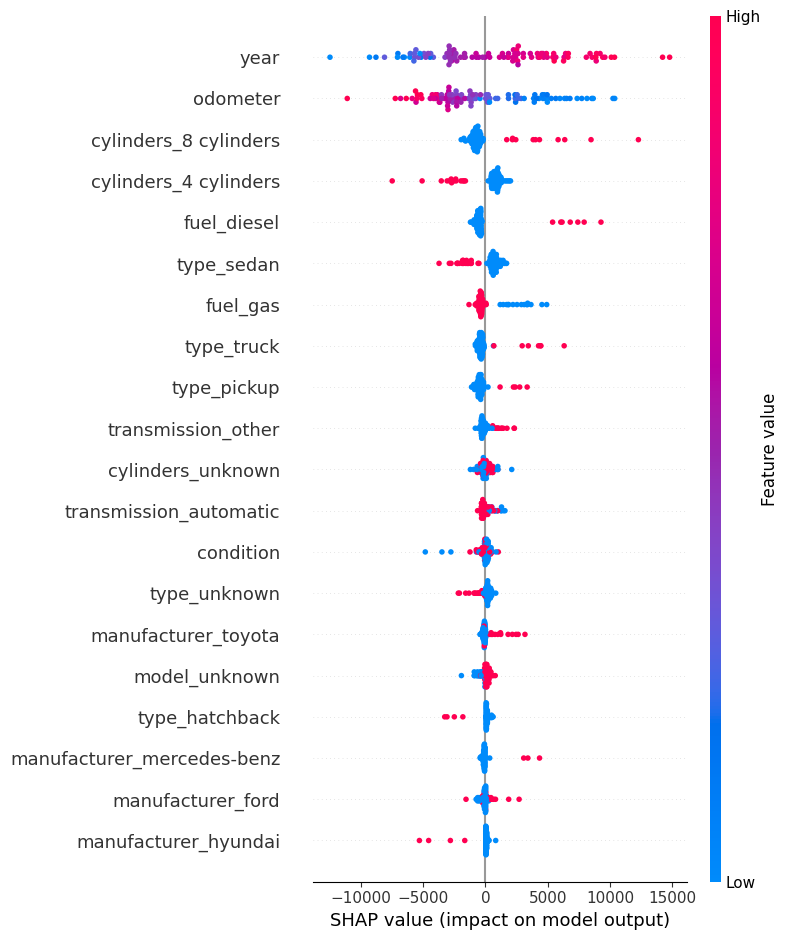

In [ ]:
ohe = pipeline.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_attribs)
all_features = list(num_attribs) + list(cat_feature_names) # We do this to give names to the features

shap.summary_plot(shap_values, X_train_prepared[:100].toarray(), feature_names=all_features)

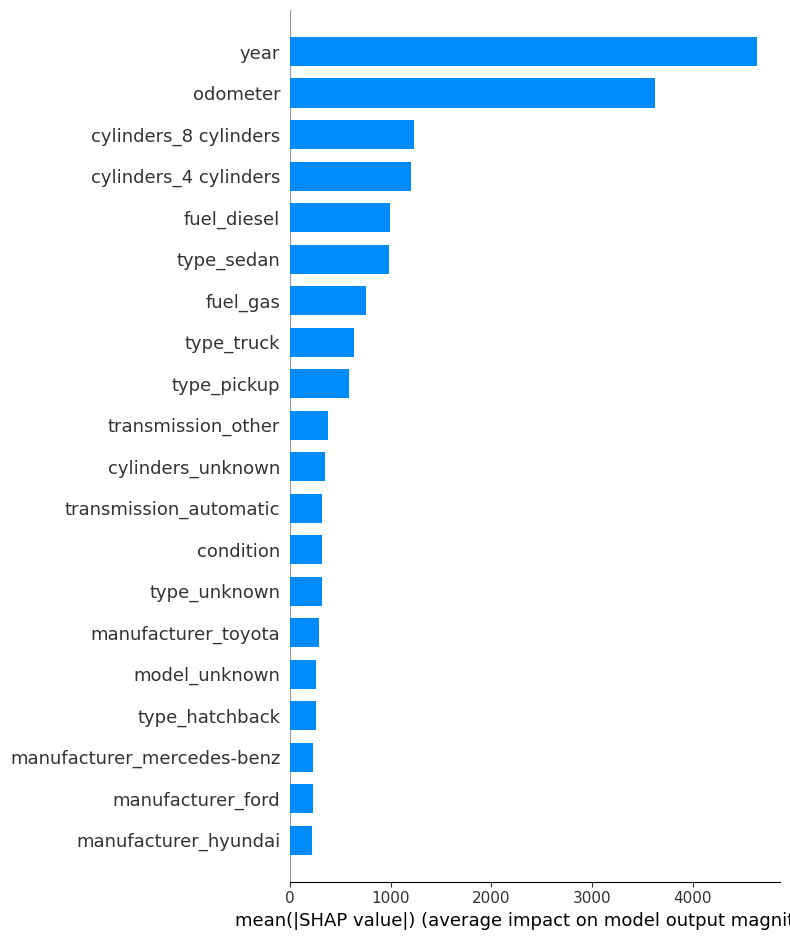

In [ ]:
#shap.plots.bar(shap_values) This doesnt work on newer versions of pandas

shap.summary_plot(shap_values, X_train_prepared[:100].toarray(), feature_names=all_features, plot_type="bar")

**Task:** Use one more method of model interpretation from Assignment 4 that would help explain the influence of features in your model.

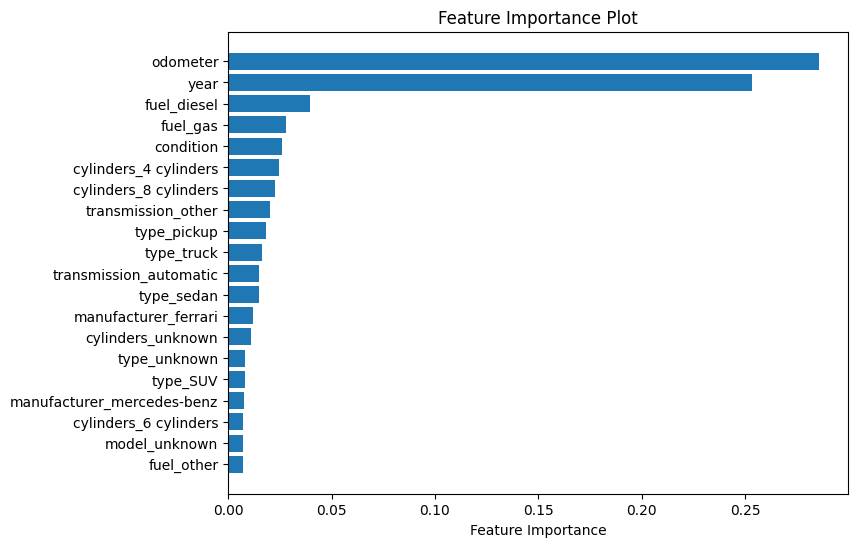

In [ ]:
indices = np.argsort(est.feature_importances_)
top_indices = indices[-20:]

plt.figure(figsize=(8, 6))
plt.barh(
    [all_features[i] for i in top_indices],
    est.feature_importances_[top_indices]
)
plt.xlabel("Feature Importance")
plt.title("Feature Importance Plot")
plt.show()

**Question:**  Do the method you chose and SHAP agree with each other in the interpretation?

**Answer:**  `They seem to agree with the top 2 features, but not on which one should be nr. 1. They seem to be in agreeance with what features are important, but not on the ordering. Shap gives more importance to the cylinders, whilst Feature importance gives more importance to fuel types and condition`

**Question:**  Discuss how possible biases could have crept in while building the above model from scratch.

**Answer:**  `Several biases could have been introduced. Missing values were filled with assumed defaults like "good" for condition and "gas" for fuel, which may not reflect reality. Rare car models were grouped as "unknown" which could confuse the model for unusual vehicles. Hyperparameter tuning was done on a small subset of 5000 samples which may not be representative of the full dataset.`

## Classification 

But unlike the last time we will not drop some of the features. We will use all the features to predict the type of the vehicle.

In [ ]:
msrp_df = pd.read_csv("../Ass2/data.csv")

In [ ]:
for col in msrp_df.columns:
    new_col = '_'.join(col.lower().split(' '))
    msrp_df.rename({col: new_col}, inplace=True, axis=1)

In [ ]:
msrp_df['is_luxury'] = msrp_df.market_category.str.contains('Luxury')

In [ ]:
msrp_train_set, msrp_test_set = train_test_split(
    msrp_df.dropna(subset=['is_luxury']), 
    test_size=0.1, 
    random_state=123)
msrp_train_df = msrp_train_set.copy()

You now again have full freedom on how to shape the dataset:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def preprocess_msrp(df_in):

    df = df_in.copy()
    
    df = df.drop(columns=['market_category', 'make', 'model', 'msrp'])
    
    df = df.dropna(subset=['engine_hp', 'engine_cylinders', 'number_of_doors'])
    df['engine_fuel_type'] = df['engine_fuel_type'].fillna('regular_unleaded')
    
    
    X = df.drop('is_luxury', axis=1)
    y = df['is_luxury'].copy()
    
    return(X,y)

X, y = preprocess_msrp(msrp_train_set)

num_attribs = list(X.select_dtypes('number'))
cat_attribs = list(X.select_dtypes('object'))

pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs)
])

X_prepared = pipeline.fit_transform(X)    

/var/folders/7v/25vl4fsd1jv9jsr72bhy8wkw0000gn/T/ipykernel_90909/2802702293.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_attribs = list(X.select_dtypes('object'))


**Task:** Train one binary classification model from Assignment 3 on the training set and report accuracy, confusion matrix, precision, recall, F$_1$ score, Precision-recall curve and AUC-ROC curve for both training and test sets.

Accuracy: 0.9426745606615919
Confusion matrix:
 [[7453  209]
 [ 401 2578]]
Precision: 0.9250089702188733
Recall: 0.8653910708291372
F1: 0.8942074228234478
Accuracy: 0.9224872231686542
Confusion matrix:
 [[836  38]
 [ 53 247]]
Precision: 0.8666666666666667
Recall: 0.8233333333333334
F1: 0.8444444444444444


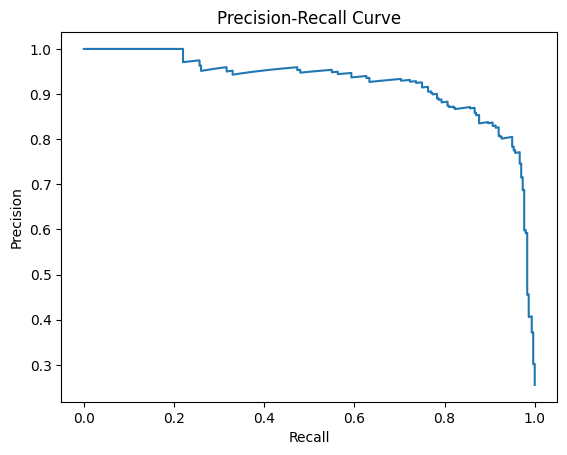

PR AUC: 0.9244412804342749


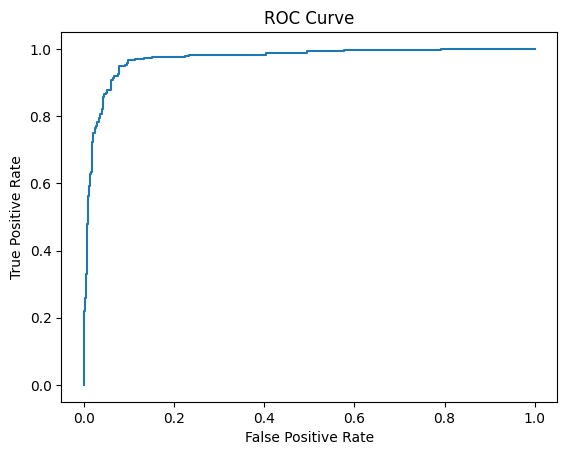

ROC AUC: 0.9712547673531655


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

svc = SVC(probability=True, random_state=42)
svc.fit(X_prepared, y)

# Training set metrics
y_train_pred = svc.predict(X_prepared)
print('Accuracy:', accuracy_score(y, y_train_pred))
print('Confusion matrix:\n', confusion_matrix(y, y_train_pred))
print('Precision:', precision_score(y, y_train_pred))
print('Recall:', recall_score(y, y_train_pred))
print('F1:', f1_score(y, y_train_pred))

# Test set metrics
X_test, y_test = preprocess_msrp(msrp_test_set)
X_test_prepared = pipeline.transform(X_test)
y_test_pred = svc.predict(X_test_prepared)
print('Accuracy:', accuracy_score(y_test, y_test_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_test_pred))
print('Precision:', precision_score(y_test, y_test_pred))
print('Recall:', recall_score(y_test, y_test_pred))
print('F1:', f1_score(y_test, y_test_pred))

# Precision-Recall curve
y_scores = svc.predict_proba(X_test_prepared)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()
print('PR AUC:', auc(recall, precision))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
print('ROC AUC:', auc(fpr, tpr))

Staistical testing to compare the two models

**Question:** Discuss the results of the above model. What would you potentially do to improve the model if given enough resources and time?

**Answer:** `The model achieves around 92% accuracy on the test set with training and test scores being close, suggesting that there is probably no significant overfitting. It performs better at identifying the non-luxury cars than luxury ones, missing some luxury cars, with a recall of 0.82. To improve the model we could tune the hyperparameters better using GridSearchCV, or create better features, like grouping manufacturers into luxury and non-luxury brands instead of removing them completely.`

**Task:** Train a logistic regression model on the msrp data and compare the results using a statistical test to determine if your model is significantly better than logistic regression trained on the msrp data.

Hint: Extract y_pred = model.predict(X_test) for both and perform the statistic test taught in class.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_prepared, y)
y_pred_lr = log_reg.predict(X_test_prepared)

print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('F1:', f1_score(y_test, y_pred_lr))

Accuracy: 0.8415672913117547
F1: 0.6748251748251748


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

y_pred_svm = svc.predict(X_test_prepared)
y_pred_lr = log_reg.predict(X_test_prepared)

#Contingency table
correct_svm = (y_pred_svm == y_test)
correct_lr = (y_pred_lr == y_test)

table = [[sum(correct_svm & correct_lr), sum(correct_svm & ~correct_lr)],
         [sum(~correct_svm & correct_lr), sum(~correct_svm & ~correct_lr)]]

print('Contingency table:', table)

result = mcnemar(table, exact=False)
print('p-value:', result.pvalue)

Contingency table: [[968, 115], [20, 71]]
p-value: 5.955125187963714e-16


`The McNemar's test gives a p-value of essentially 0, which is far below the 0.05 significance threshold. This means the difference in performance between SVM and Logistic Regression is statistically significant, and we can conclude that SVM is significantly better than Logistic Regression at predicting whether a car is luxury or not.`

## You have now completed a End-to-end Machine Learning project in both Regression and Classification!!!

Congratulations and good luck with your project.